# Análise dos Experimentos — WebKB 10-fold CV

Pasta de resultados: `results/webkb-10cv-20260504-145448-f5ee59`

**Modos analisados:**
- `baseline` — treino direto sem currículo e sem IS
- `is` — treino com Instance Selection (IS), sem currículo
- `cl` — treino com Curriculum Learning (CL), sem IS
- `is_cl` — treino com IS + CL combinados

Intervalo de confiança: **95%** (bootstrap t-distribution)

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
from pathlib import Path

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

RESULTS_DIR = Path('results/webkb-10cv-20260504-145448-f5ee59')
MODES = ['baseline', 'is', 'cl', 'is_cl']
N_FOLDS = 10
CI_ALPHA = 0.05  # 95% CI

MODE_LABELS = {
    'baseline': 'Baseline',
    'is': 'IS',
    'cl': 'CL',
    'is_cl': 'IS + CL',
}
MODE_COLORS = {
    'baseline': '#4C72B0',
    'is':       '#DD8452',
    'cl':       '#55A868',
    'is_cl':    '#C44E52',
}

def ci95(values):
    """95% confidence interval via t-distribution."""
    n = len(values)
    if n < 2:
        return (np.nan, np.nan)
    m = np.mean(values)
    se = stats.sem(values)
    h = se * stats.t.ppf(1 - CI_ALPHA / 2, df=n - 1)
    return (m - h, m + h)

print('Setup concluído.')

Setup concluído.


## 1. Carregamento dos dados e verificação de completude

In [3]:
timings_rows = []
phase_metrics_rows = []
train_history_rows = []
completeness = {m: [] for m in MODES}  # fold -> status

EXPECTED_PHASES = {
    'baseline': {'full'},
    'is':       {'full'},
    'cl':       {'clean', 'diverse', 'hard'},
    'is_cl':    {'clean', 'diverse', 'hard'},
}

for mode in MODES:
    for fold in range(N_FOLDS):
        fold_dir = RESULTS_DIR / f'{mode}_fold{fold}'
        status = 'ok'

        # --- timings ---
        t_file = fold_dir / 'timings.csv'
        if t_file.exists():
            t = pd.read_csv(t_file, index_col='name')['seconds'].to_dict()
            t.update({'mode': mode, 'fold': fold})
            timings_rows.append(t)
        else:
            status = 'sem timings'

        # --- phase_metrics ---
        pm_file = fold_dir / 'phase_metrics.csv'
        if pm_file.exists():
            pm = pd.read_csv(pm_file)
            pm['mode'] = mode
            pm['fold'] = fold
            phase_metrics_rows.append(pm)
            # Check completeness
            observed = set(pm['phase'].unique())
            expected = EXPECTED_PHASES[mode]
            if not expected.issubset(observed):
                status = f'incompleto (fases: {sorted(observed)})'
        else:
            status = 'sem phase_metrics'

        # --- train_history ---
        th_file = fold_dir / 'train_history.csv'
        if th_file.exists():
            th = pd.read_csv(th_file)
            th['mode'] = mode
            th['fold'] = fold
            train_history_rows.append(th)

        completeness[mode].append({'fold': fold, 'status': status})

df_timings = pd.DataFrame(timings_rows)
df_pm      = pd.concat(phase_metrics_rows, ignore_index=True)
df_th      = pd.concat(train_history_rows, ignore_index=True)

print(f'Timings carregados: {len(df_timings)} entradas')
print(f'Phase metrics: {len(df_pm)} linhas')
print(f'Train history: {len(df_th)} linhas')

Timings carregados: 40 entradas
Phase metrics: 62 linhas
Train history: 54736 linhas


### 1.1 Experimentos incompletos por modo

In [4]:
summary_rows = []
for mode in MODES:
    ok     = sum(1 for x in completeness[mode] if x['status'] == 'ok')
    failed = N_FOLDS - ok
    failed_folds = [x['fold'] for x in completeness[mode] if x['status'] != 'ok']
    failed_reasons = [x['status'] for x in completeness[mode] if x['status'] != 'ok']
    summary_rows.append({
        'Modo': MODE_LABELS[mode],
        'Completos': ok,
        'Incompletos': failed,
        'Folds com falha': str(failed_folds) if failed_folds else '—',
        'Motivo': failed_reasons[0] if failed_reasons else '—',
    })

df_completeness = pd.DataFrame(summary_rows).set_index('Modo')
print('Resumo de completude dos experimentos (10 folds por modo):\n')
display(df_completeness)

# Detail
print('\nDetalhe por fold:')
for mode in MODES:
    issues = [(x['fold'], x['status']) for x in completeness[mode] if x['status'] != 'ok']
    if issues:
        for fold, reason in issues:
            print(f'  [{MODE_LABELS[mode]}] fold {fold}: {reason}')

Resumo de completude dos experimentos (10 folds por modo):



,Completos,Incompletos,Folds com falha,Motivo
Modo,,,,
Baseline,10,0,—,—
IS,10,0,—,—
CL,6,4,"[4, 6, 7, 9]",incompleto (fases: ['clean'])
IS + CL,5,5,"[4, 5, 6, 7, 9]",incompleto (fases: ['clean'])



Detalhe por fold:
  [CL] fold 4: incompleto (fases: ['clean'])
  [CL] fold 6: incompleto (fases: ['clean'])
  [CL] fold 7: incompleto (fases: ['clean'])
  [CL] fold 9: incompleto (fases: ['clean'])
  [IS + CL] fold 4: incompleto (fases: ['clean'])
  [IS + CL] fold 5: incompleto (fases: ['clean'])
  [IS + CL] fold 6: incompleto (fases: ['clean'])
  [IS + CL] fold 7: incompleto (fases: ['clean'])
  [IS + CL] fold 9: incompleto (fases: ['clean'])


## 2. Análise dos tempos de treinamento

> **Nota:** Para modos CL e IS+CL, são incluídos apenas os folds completos (todas as fases concluídas).

In [5]:
# Folds completos por modo
complete_folds = {}
for mode in MODES:
    complete_folds[mode] = [x['fold'] for x in completeness[mode] if x['status'] == 'ok']

def get_timing_values(df_timings, mode, col):
    sub = df_timings[(df_timings['mode'] == mode) & (df_timings['fold'].isin(complete_folds[mode]))]
    return sub[col].dropna().values

def describe_series(values, label):
    lo, hi = ci95(values)
    return {
        'Modo': label,
        'n': len(values),
        'Média (s)': np.mean(values),
        'Mediana (s)': np.median(values),
        'Std (s)': np.std(values, ddof=1),
        'Min (s)': np.min(values),
        'Max (s)': np.max(values),
        'IC95% inferior': lo,
        'IC95% superior': hi,
    }

# Collect data
train_times  = {m: get_timing_values(df_timings, m, 'model_train_time_s') for m in MODES}
total_times  = {m: get_timing_values(df_timings, m, 'total_run_time_s')   for m in MODES}

print('Dados de tempo coletados.')
for m in MODES:
    print(f'  {MODE_LABELS[m]}: {len(train_times[m])} folds completos')

Dados de tempo coletados.
  Baseline: 10 folds completos
  IS: 10 folds completos
  CL: 6 folds completos
  IS + CL: 5 folds completos


### 2.1 Tempo de treinamento do modelo (`model_train_time_s`)

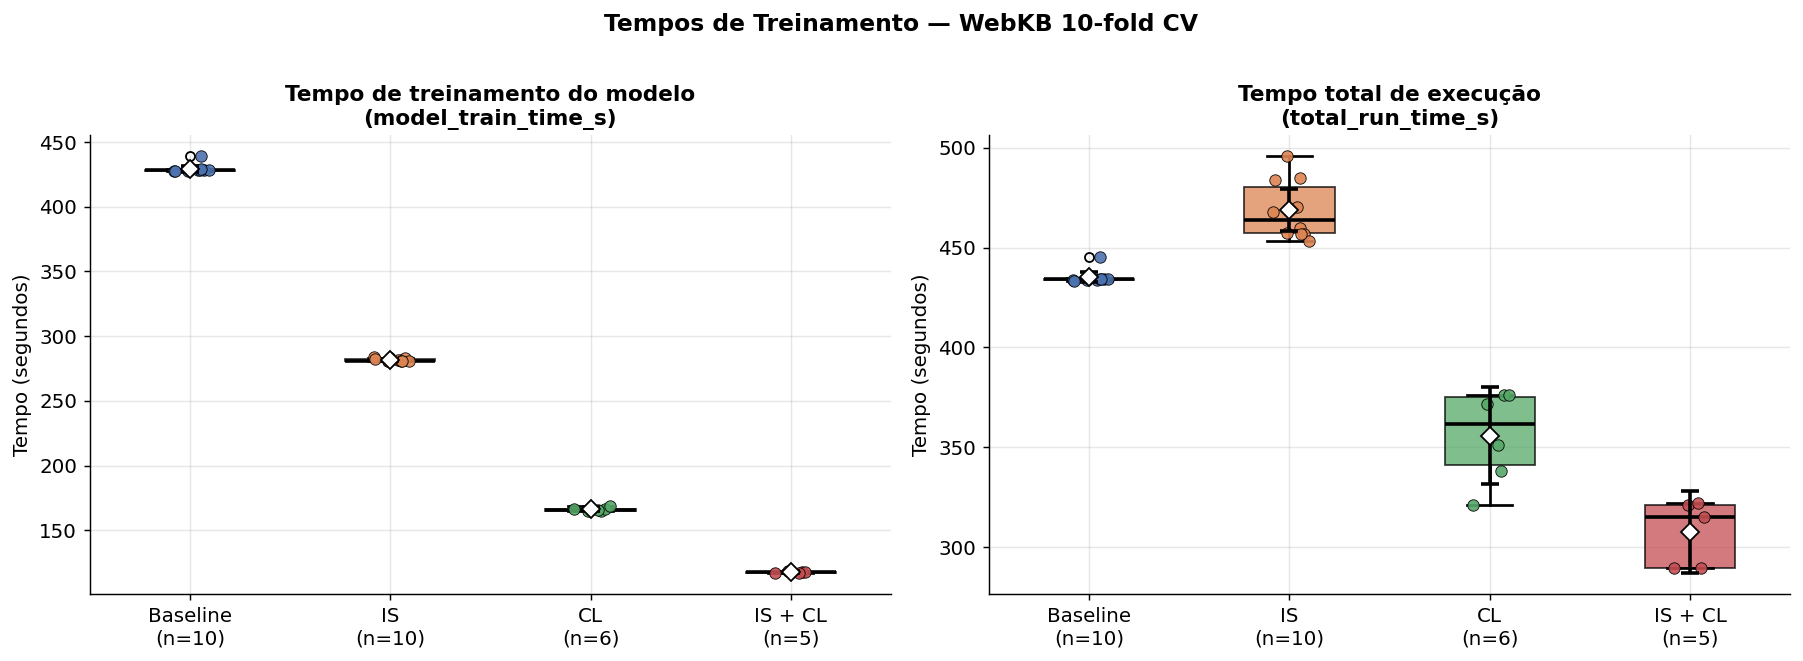

Diamante = média  |  Barra = IC 95%  |  Pontos = folds individuais


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (times_dict, title, col) in zip(axes, [
    (train_times, 'Tempo de treinamento do modelo\n(model_train_time_s)', 'model_train_time_s'),
    (total_times, 'Tempo total de execução\n(total_run_time_s)', 'total_run_time_s'),
]):
    data   = [times_dict[m] for m in MODES]
    labels = [f"{MODE_LABELS[m]}\n(n={len(times_dict[m])})" for m in MODES]
    colors = [MODE_COLORS[m] for m in MODES]

    bp = ax.boxplot(
        data, labels=labels, patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=5),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Overlay individual points
    for i, (vals, color) in enumerate(zip(data, colors), start=1):
        jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=color, edgecolor='black', linewidth=0.5,
                   zorder=5, s=40, alpha=0.9)

    # CI error bars for the mean
    for i, (m, vals) in enumerate(zip(MODES, data), start=1):
        if len(vals) >= 2:
            lo, hi = ci95(vals)
            mean   = np.mean(vals)
            ax.errorbar(i, mean, yerr=[[mean - lo], [hi - mean]],
                        fmt='D', color='white', ecolor='black',
                        elinewidth=2, capsize=5, capthick=2,
                        markersize=7, zorder=10, markeredgecolor='black')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Tempo (segundos)')

plt.suptitle('Tempos de Treinamento — WebKB 10-fold CV', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('Diamante = média  |  Barra = IC 95%  |  Pontos = folds individuais')

### 2.2 Estatísticas descritivas dos tempos

In [7]:
print('=== TEMPO DE TREINAMENTO DO MODELO (model_train_time_s) ===')
rows = [describe_series(train_times[m], MODE_LABELS[m]) for m in MODES]
df_train_desc = pd.DataFrame(rows).set_index('Modo')
display(df_train_desc.round(2))

print('\n=== TEMPO TOTAL DE EXECUÇÃO (total_run_time_s) ===')
rows = [describe_series(total_times[m], MODE_LABELS[m]) for m in MODES]
df_total_desc = pd.DataFrame(rows).set_index('Modo')
display(df_total_desc.round(2))

=== TEMPO DE TREINAMENTO DO MODELO (model_train_time_s) ===


,n,Média (s),Mediana (s),Std (s),Min (s),Max (s),IC95% inferior,IC95% superior
Modo,,,,,,,,
Baseline,10,429.23,428.11,3.45,427.53,438.97,426.77,431.70
IS,10,281.73,281.15,1.12,280.74,283.97,280.93,282.53
CL,6,166.10,166.00,1.44,164.57,168.50,164.59,167.62
IS + CL,5,117.48,117.52,0.62,116.61,118.33,116.71,118.24



=== TEMPO TOTAL DE EXECUÇÃO (total_run_time_s) ===


,n,Média (s),Mediana (s),Std (s),Min (s),Max (s),IC95% inferior,IC95% superior
Modo,,,,,,,,
Baseline,10,435.17,434.15,3.50,433.09,445.05,432.67,437.68
IS,10,468.70,463.91,14.72,453.24,495.76,458.17,479.23
CL,6,355.77,361.42,23.02,321.06,376.41,331.62,379.93
IS + CL,5,307.31,314.90,16.56,289.36,321.94,286.75,327.88


### 2.3 Decomposição do tempo total (stacked bar)

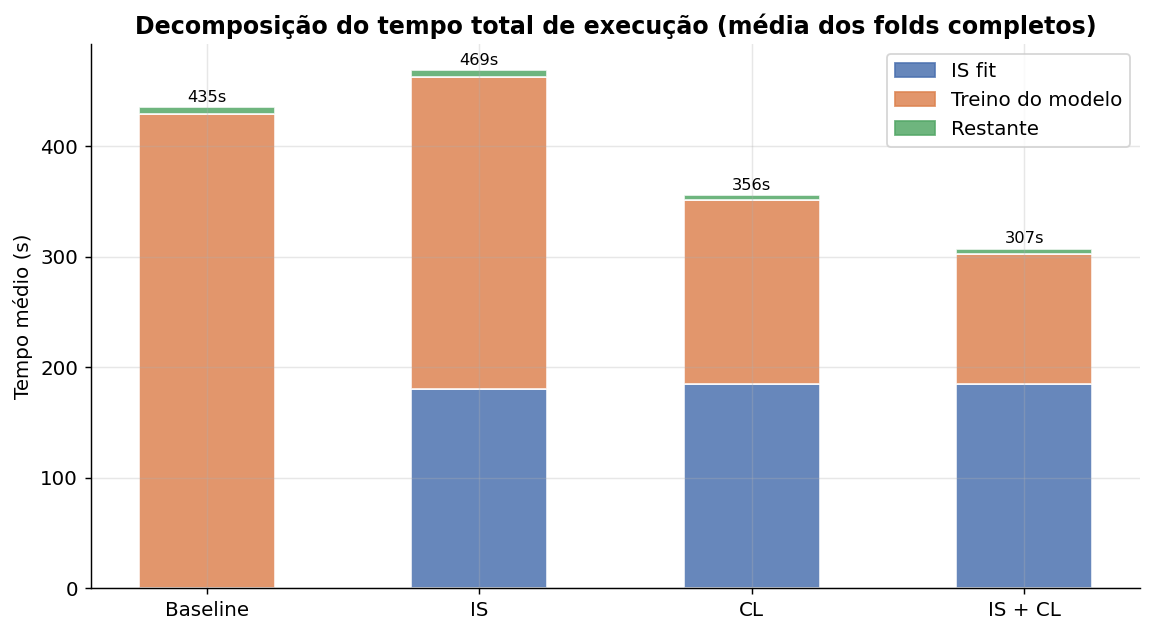

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

def _mean_or_zero(sub_df, col):
    """Média segura: coluna ausente ou só NaN → 0 (evita barras invisíveis no stacked bar)."""
    if col not in sub_df.columns:
        return 0.0
    m = sub_df[col].mean()
    return 0.0 if pd.isna(m) else float(m)

comp_colors = ['#4C72B0', '#DD8452', '#55A868']
comp_labels = ['IS fit', 'Treino do modelo', 'Restante']

x = np.arange(len(MODES))
width = 0.5

for idx, mode in enumerate(MODES):
    sub = df_timings[(df_timings['mode'] == mode) & (df_timings['fold'].isin(complete_folds[mode]))]
    total_mean = float(sub['total_run_time_s'].mean())

    is_fit  = _mean_or_zero(sub, 'is_fit_time_s')
    train_t = _mean_or_zero(sub, 'model_train_time_s')
    rest    = max(0.0, total_mean - is_fit - train_t)

    bottom = 0.0
    for val, color in zip([is_fit, train_t, rest], comp_colors):
        ax.bar(idx, val, width, bottom=bottom, color=color, alpha=0.85, edgecolor='white')
        bottom += val

    ax.text(idx, total_mean + 2, f'{total_mean:.0f}s', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([MODE_LABELS[m] for m in MODES])
ax.set_ylabel('Tempo médio (s)')
ax.set_title('Decomposição do tempo total de execução (média dos folds completos)',
             fontweight='bold')
patches = [mpatches.Patch(color=c, label=l, alpha=0.85)
           for c, l in zip(comp_colors, comp_labels)]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.show()


## 3. Histórico de perda por época

> **Nota:** O `train_history.csv` registra **perda (loss) por step**, não acurácia.
> A acurácia só é avaliada ao final de cada fase de currículo (em `phase_metrics.csv`).
> Portanto, o histórico de treinamento é apresentado como **loss médio por época**,
> agrupado por modo e fase. A evolução da acurácia pelas fases de currículo
> é mostrada na Seção 3.2.

In [9]:
# Compute per-epoch mean loss  (group by mode, fold, phase, epoch)
df_epoch = (
    df_th
    .groupby(['mode', 'fold', 'phase', 'epoch'])['loss']
    .mean()
    .reset_index()
    .rename(columns={'loss': 'mean_loss'})
)

# For CL modes, we build a global 'training step' index:
#   encode phase order as an offset to the epoch so phases appear in sequence
PHASE_ORDER = {'full': 0, 'clean': 0, 'diverse': 1, 'hard': 2}
PHASE_EPOCHS = {}  # will be filled below

def build_global_epoch(sub):
    """Assign a monotonically increasing global epoch across phases."""
    sub = sub.copy().sort_values(['phase', 'epoch'])
    offset = 0
    rows = []
    for ph in sorted(sub['phase'].unique(), key=lambda p: PHASE_ORDER.get(p, 99)):
        ph_df = sub[sub['phase'] == ph].copy()
        ph_df['global_epoch'] = ph_df['epoch'] + offset
        offset = ph_df['global_epoch'].max()
        rows.append(ph_df)
    return pd.concat(rows)

# Apply per fold
parts = []
for (mode, fold), grp in df_epoch.groupby(['mode', 'fold']):
    parts.append(build_global_epoch(grp))
df_epoch_global = pd.concat(parts, ignore_index=True)

print('Histórico de perda por época preparado.')
print(df_epoch_global.head())

Histórico de perda por época preparado.
       mode  fold phase  epoch  mean_loss  global_epoch
0  baseline     0  full      1   1.576025             1
1  baseline     0  full      2   1.535105             2
2  baseline     0  full      3   1.528406             3
3  baseline     0  full      4   1.527876             4
4  baseline     0  full      5   1.526368             5


### 3.1 Loss médio por época — todos os modos com IC 95%

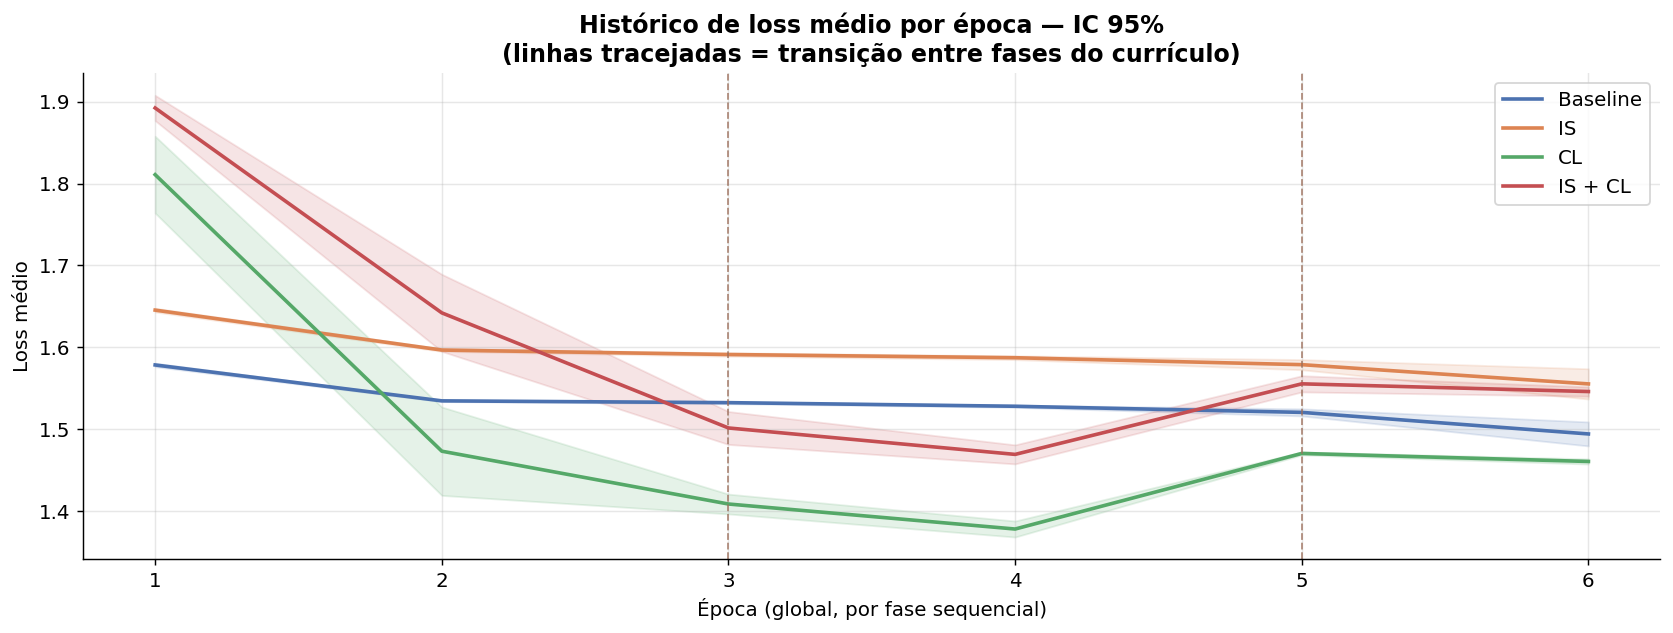

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))

for mode in MODES:
    sub = df_epoch_global[
        (df_epoch_global['mode'] == mode) &
        (df_epoch_global['fold'].isin(complete_folds[mode]))
    ]
    if sub.empty:
        continue

    agg = sub.groupby('global_epoch')['mean_loss'].agg(['mean', 'std', 'count'])
    agg = agg[agg['count'] >= 2].copy()
    agg['se']   = agg['std'] / np.sqrt(agg['count'])
    agg['t']    = stats.t.ppf(1 - CI_ALPHA / 2, df=agg['count'] - 1)
    agg['lo']   = agg['mean'] - agg['t'] * agg['se']
    agg['hi']   = agg['mean'] + agg['t'] * agg['se']

    epochs = agg.index.values
    color  = MODE_COLORS[mode]
    ax.plot(epochs, agg['mean'], label=MODE_LABELS[mode], color=color, linewidth=2)
    ax.fill_between(epochs, agg['lo'], agg['hi'], color=color, alpha=0.15)

    # Mark phase transitions for CL modes
    if mode in ('cl', 'is_cl'):
        sub_fold0 = sub[sub['fold'] == complete_folds[mode][0]]
        for ph in ['diverse', 'hard']:
            ph_start = sub_fold0[sub_fold0['phase'] == ph]['global_epoch'].min()
            if not np.isnan(ph_start):
                ax.axvline(ph_start, color=color, linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Época (global, por fase sequencial)')
ax.set_ylabel('Loss médio')
ax.set_title('Histórico de loss médio por época — IC 95%\n'
             '(linhas tracejadas = transição entre fases do currículo)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Acurácia ao final de cada fase de currículo

Como a acurácia só é registrada ao final de cada fase, apresentamos sua evolução entre as fases.

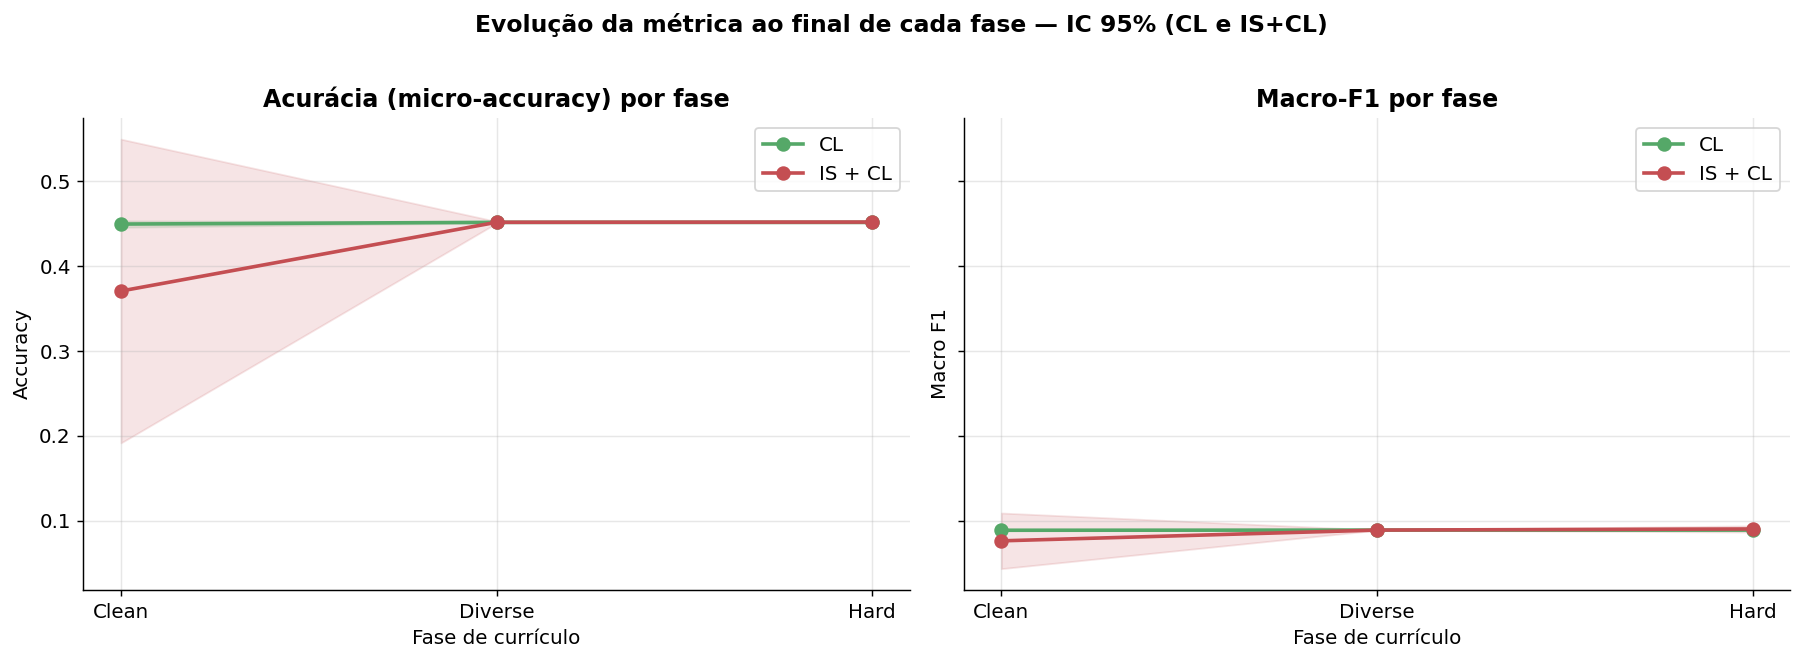

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

MODES_CURRICULUM = ('cl', 'is_cl')
CURRICULUM_PHASES = ('clean', 'diverse', 'hard')
PHASE_NAMES = {'clean': 'Clean', 'diverse': 'Diverse', 'hard': 'Hard'}

for ax, metric, title in zip(axes,
    ['accuracy', 'macro_f1'],
    ['Acurácia (micro-accuracy) por fase', 'Macro-F1 por fase']):

    for mode in MODES_CURRICULUM:
        sub = df_pm[
            (df_pm['mode'] == mode) &
            (df_pm['fold'].isin(complete_folds[mode]))
        ]
        phases_sorted = [p for p in CURRICULUM_PHASES if p in sub['phase'].unique()]
        xs, means, lows, highs = [], [], [], []
        for ph in phases_sorted:
            vals = sub[sub['phase'] == ph][metric].values
            if len(vals) < 1:
                continue
            lo, hi = ci95(vals) if len(vals) >= 2 else (vals[0], vals[0])
            xs.append(PHASE_NAMES.get(ph, ph))
            means.append(np.mean(vals))
            lows.append(lo)
            highs.append(hi)

        x_num = np.arange(len(xs))
        color = MODE_COLORS[mode]
        ax.plot(x_num, means, 'o-', label=MODE_LABELS[mode], color=color, linewidth=2, markersize=7)
        ax.fill_between(x_num, lows, highs, color=color, alpha=0.15)

    ax.set_xticks(np.arange(len(CURRICULUM_PHASES)))
    ax.set_xticklabels([PHASE_NAMES[p] for p in CURRICULUM_PHASES])
    ax.set_xlabel('Fase de currículo')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Evolução da métrica ao final de cada fase — IC 95% (CL e IS+CL)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Projeto 2² — Análise fatorial (IS × CL)

Os 4 modos formam um **delineamento fatorial 2²** com:
- Fator **A = IS** (Instance Selection): 0 = não, 1 = sim  
- Fator **B = CL** (Curriculum Learning): 0 = não, 1 = sim

| Modo | IS (A) | CL (B) |
|------|--------|--------|
| baseline | 0 | 0 |
| is | 1 | 0 |
| cl | 0 | 1 |
| is_cl | 1 | 1 |

Resposta: **acurácia** (`accuracy`) na última fase avaliada.

> Apenas os **folds completos** são utilizados por célula do delineamento.

In [12]:
# Build the 2^2 design dataframe
factor_map = {
    'baseline': (0, 0),
    'is':       (1, 0),
    'cl':       (0, 1),
    'is_cl':    (1, 1),
}

design_rows = []
for mode in MODES:
    # Use the final phase accuracy for complete folds
    sub = df_pm[
        (df_pm['mode'] == mode) &
        (df_pm['fold'].isin(complete_folds[mode]))
    ]
    # Last phase per fold
    last = (
        sub.sort_values('phase', key=lambda s: s.map(PHASE_ORDER))
        .groupby('fold')
        .last()
        .reset_index()
    )
    A, B = factor_map[mode]
    for _, row in last.iterrows():
        design_rows.append({
            'mode': mode,
            'fold': row['fold'],
            'IS':   A,
            'CL':   B,
            'accuracy': row['accuracy'],
            'micro_f1': row['micro_f1'],
            'macro_f1': row['macro_f1'],
        })

df_design = pd.DataFrame(design_rows)

# Count per cell
cell_counts = df_design.groupby('mode').size().rename('n folds completos')
print('Observações por célula do delineamento 2²:')
display(cell_counts.to_frame())

MIN_OBS = 2
cells_ok = all(v >= MIN_OBS for v in cell_counts.values)
print(f'\nTodas as células com >= {MIN_OBS} observações? {cells_ok}')

Observações por célula do delineamento 2²:


,n folds completos
mode,
baseline,10
cl,6
is,10
is_cl,5



Todas as células com >= 2 observações? True


In [13]:
if not cells_ok:
    print('⚠ Não há observações suficientes em alguma célula do delineamento.')
    print('  O projeto 2² não pode ser executado com confiabilidade.')
else:
    # ---- 2^2 ANOVA — Type III SS via nested model comparison ----
    # Coding: IS, CL ∈ {-1, +1}  (sum-to-zero / effects coding)
    df_design['A']  = df_design['IS'].map({0: -1, 1: +1})
    df_design['B']  = df_design['CL'].map({0: -1, 1: +1})
    df_design['AB'] = df_design['A'] * df_design['B']

    response = 'accuracy'
    y       = df_design[response].values
    n_total = len(y)
    grand_mean = y.mean()

    from numpy.linalg import lstsq

    def fit_ss_res(X, y):
        coef, _, _, _ = lstsq(X, y, rcond=None)
        return np.sum((y - X @ coef) ** 2)

    ones = np.ones(n_total)
    A    = df_design['A'].values
    B    = df_design['B'].values
    AB   = df_design['AB'].values

    # Full model: intercept + A + B + AB
    X_full = np.column_stack([ones, A, B, AB])
    ss_res_full = fit_ss_res(X_full, y)

    # Type III SS: compare full model with model that drops each term
    ss_res_noA  = fit_ss_res(np.column_stack([ones, B, AB]), y)
    ss_res_noB  = fit_ss_res(np.column_stack([ones, A, AB]), y)
    ss_res_noAB = fit_ss_res(np.column_stack([ones, A, B]),  y)

    ss_A  = ss_res_noA  - ss_res_full   # Type III SS for IS
    ss_B  = ss_res_noB  - ss_res_full   # Type III SS for CL
    ss_AB = ss_res_noAB - ss_res_full   # Type III SS for IS×CL

    ss_tot = np.sum((y - grand_mean) ** 2)
    ss_res = ss_res_full

    # Variance explained (% of total SS)
    pct_A  = 100 * ss_A  / ss_tot
    pct_B  = 100 * ss_B  / ss_tot
    pct_AB = 100 * ss_AB / ss_tot
    pct_e  = 100 * ss_res / ss_tot

    # Cell means for effect interpretation
    cell_means = df_design.groupby(['IS', 'CL'])[response].mean()
    y00 = cell_means.get((0, 0), np.nan)
    y10 = cell_means.get((1, 0), np.nan)
    y01 = cell_means.get((0, 1), np.nan)
    y11 = cell_means.get((1, 1), np.nan)

    effect_A  = 0.5 * ((y10 - y00) + (y11 - y01))
    effect_B  = 0.5 * ((y01 - y00) + (y11 - y10))
    effect_AB = 0.5 * ((y11 - y01) - (y10 - y00))

    print('=' * 60)
    print('PROJETO 2² — Análise fatorial: IS × CL')
    print(f'Resposta: {response}  |  N = {n_total} observações totais')
    print('(SS Tipo III — comparação de modelos aninhados)')
    print('=' * 60)
    print(f'\nMédias por célula:')
    print(f'  baseline  (IS=0, CL=0): {y00:.5f}')
    print(f'  is        (IS=1, CL=0): {y10:.5f}')
    print(f'  cl        (IS=0, CL=1): {y01:.5f}')
    print(f'  is_cl     (IS=1, CL=1): {y11:.5f}')

    print(f'\nEfeitos (diferença média atribuída a cada fator):')
    print(f'  A (IS):     {effect_A:+.6f}')
    print(f'  B (CL):     {effect_B:+.6f}')
    print(f'  AB (IS×CL): {effect_AB:+.6f}')

    print(f'\nVariância explicada (SS Tipo III / SS_total):')
    print(f'  A  (IS):      {pct_A:.2f}%')
    print(f'  B  (CL):      {pct_B:.2f}%')
    print(f'  AB (IS×CL):   {pct_AB:.2f}%')
    print(f'  Erro/resíduo: {pct_e:.2f}%')

PROJETO 2² — Análise fatorial: IS × CL
Resposta: accuracy  |  N = 31 observações totais
(SS Tipo III — comparação de modelos aninhados)

Médias por célula:
  baseline  (IS=0, CL=0): 0.44287
  is        (IS=1, CL=0): 0.44175
  cl        (IS=0, CL=1): 0.45167
  is_cl     (IS=1, CL=1): 0.45200

Efeitos (diferença média atribuída a cada fator):
  A (IS):     -0.000392
  B (CL):     +0.009521
  AB (IS×CL): +0.000725

Variância explicada (SS Tipo III / SS_total):
  A  (IS):      0.03%
  B  (CL):      15.11%
  AB (IS×CL):   0.09%
  Erro/resíduo: 84.71%


### 4.1 Gráfico de efeitos principais e interação

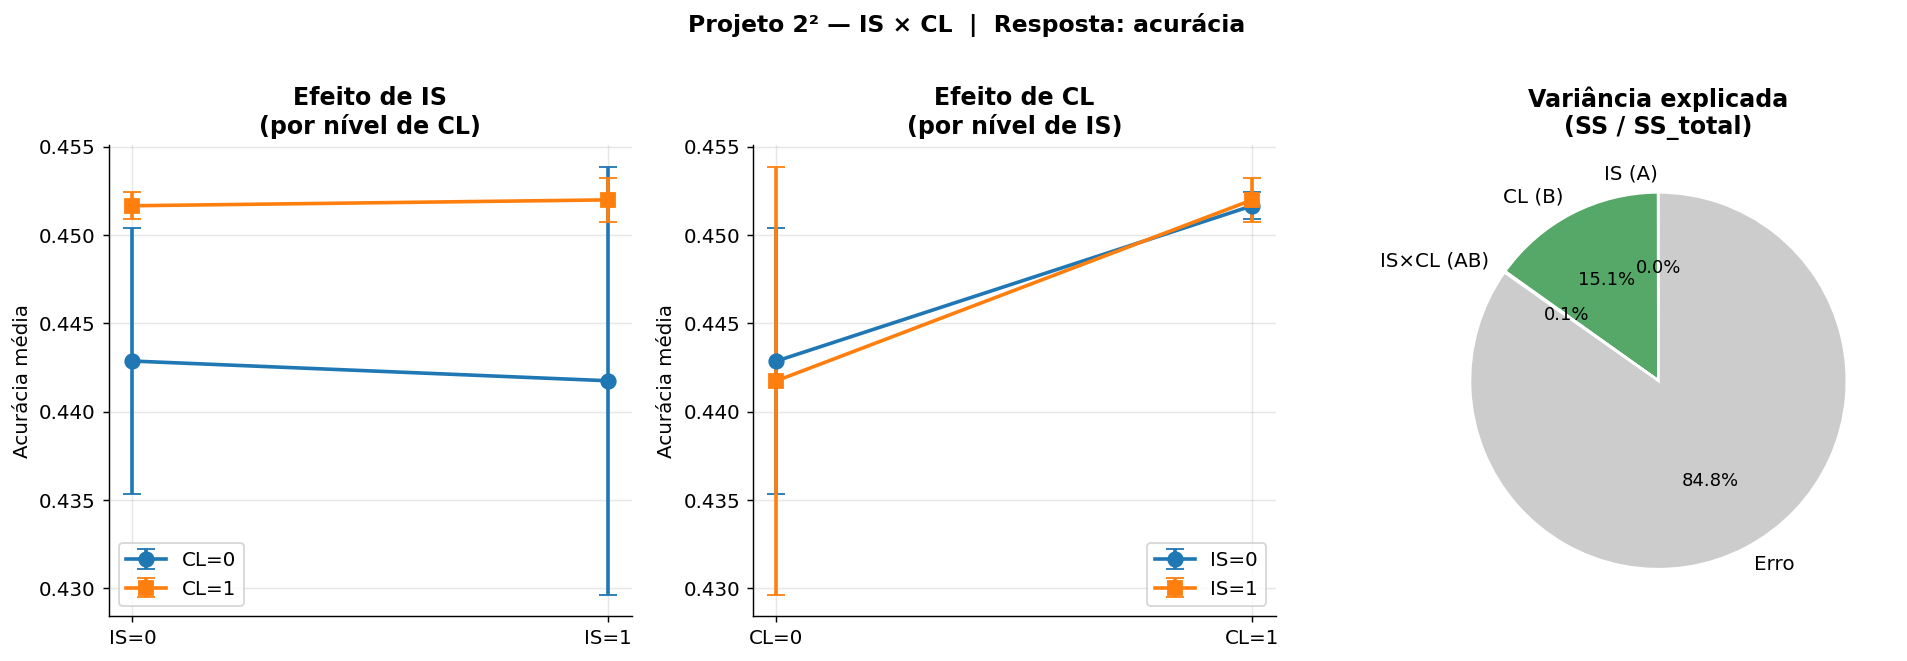

In [14]:
if cells_ok:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # --- (a) Efeito de IS ---
    ax = axes[0]
    for cl_val, ls, lbl in [(0, '-o', 'CL=0'), (1, '-s', 'CL=1')]:
        sub = df_design[df_design['CL'] == cl_val]
        grp = sub.groupby('IS')[response].agg(['mean', 'std', 'count'])
        grp['se'] = grp['std'] / np.sqrt(grp['count'])
        grp['h']  = grp['se'] * stats.t.ppf(1 - CI_ALPHA/2, df=grp['count']-1)
        ax.errorbar(grp.index, grp['mean'], yerr=grp['h'], fmt=ls,
                    capsize=5, linewidth=2, markersize=8, label=lbl)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['IS=0', 'IS=1'])
    ax.set_ylabel('Acurácia média')
    ax.set_title('Efeito de IS\n(por nível de CL)', fontweight='bold')
    ax.legend()

    # --- (b) Efeito de CL ---
    ax = axes[1]
    for is_val, ls, lbl in [(0, '-o', 'IS=0'), (1, '-s', 'IS=1')]:
        sub = df_design[df_design['IS'] == is_val]
        grp = sub.groupby('CL')[response].agg(['mean', 'std', 'count'])
        grp['se'] = grp['std'] / np.sqrt(grp['count'])
        grp['h']  = grp['se'] * stats.t.ppf(1 - CI_ALPHA/2, df=grp['count']-1)
        ax.errorbar(grp.index, grp['mean'], yerr=grp['h'], fmt=ls,
                    capsize=5, linewidth=2, markersize=8, label=lbl)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['CL=0', 'CL=1'])
    ax.set_ylabel('Acurácia média')
    ax.set_title('Efeito de CL\n(por nível de IS)', fontweight='bold')
    ax.legend()

    # --- (c) Variância explicada (pie) ---
    ax = axes[2]
    labels_pie = ['IS (A)', 'CL (B)', 'IS×CL (AB)', 'Erro']
    sizes_pie  = [pct_A, pct_B, pct_AB, pct_e]
    colors_pie = ['#4C72B0', '#55A868', '#C44E52', '#CCCCCC']
    wedges, texts, autotexts = ax.pie(
        sizes_pie, labels=labels_pie, autopct='%1.1f%%',
        colors=colors_pie, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
    )
    for at in autotexts:
        at.set_fontsize(10)
    ax.set_title('Variância explicada\n(SS / SS_total)', fontweight='bold')

    plt.suptitle('Projeto 2² — IS × CL  |  Resposta: acurácia', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

### 4.2 Tabela ANOVA completa do projeto 2²

In [14]:
if cells_ok:
    gl_erro = n_total - 4  # 4 params: intercept, A, B, AB
    ms_e    = ss_res / gl_erro

    df_anova = pd.DataFrame([
        {'Fonte':    'A — IS',
         'SS':       ss_A,
         'GL':       1,
         'MS':       ss_A,
         'Efeito':   effect_A,
         '% var':    pct_A,
         'F':        ss_A / ms_e,
         'p-valor':  1 - stats.f.cdf(ss_A / ms_e, 1, gl_erro)},
        {'Fonte':    'B — CL',
         'SS':       ss_B,
         'GL':       1,
         'MS':       ss_B,
         'Efeito':   effect_B,
         '% var':    pct_B,
         'F':        ss_B / ms_e,
         'p-valor':  1 - stats.f.cdf(ss_B / ms_e, 1, gl_erro)},
        {'Fonte':    'AB — IS×CL',
         'SS':       ss_AB,
         'GL':       1,
         'MS':       ss_AB,
         'Efeito':   effect_AB,
         '% var':    pct_AB,
         'F':        ss_AB / ms_e,
         'p-valor':  1 - stats.f.cdf(ss_AB / ms_e, 1, gl_erro)},
        {'Fonte':    'Erro (resíduo)',
         'SS':       ss_res,
         'GL':       gl_erro,
         'MS':       ms_e,
         'Efeito':   np.nan,
         '% var':    pct_e,
         'F':        np.nan,
         'p-valor':  np.nan},
        {'Fonte':    'Total',
         'SS':       ss_tot,
         'GL':       n_total - 1,
         'MS':       np.nan,
         'Efeito':   np.nan,
         '% var':    pct_A + pct_B + pct_AB + pct_e,
         'F':        np.nan,
         'p-valor':  np.nan},
    ]).set_index('Fonte')

    print('Tabela ANOVA — Projeto 2² (SS Tipo III)\n')
    display(df_anova.round(6))

    print('\nNota: % var = SS_fator / SS_total  (variância explicada em relação à variação total).')
    print('      Como o delineamento é não-balanceado, a soma das % pode diferir de 100%.')

Tabela ANOVA — Projeto 2² (SS Tipo III)



,SS,GL,MS,Efeito,% var,F,p-valor
Fonte,,,,,,,
A — IS,0.000001,1,0.000001,-0.000392,0.025646,0.008174,0.928627
B — CL,0.000640,1,0.000640,0.009521,15.105085,4.814661,0.037003
AB — IS×CL,0.000004,1,0.000004,0.000725,0.087664,0.027942,0.868490
Erro (resíduo),0.003589,27,0.000133,NaN,84.707381,NaN,NaN
Total,0.004237,30,NaN,NaN,99.925777,NaN,NaN



Nota: % var = SS_fator / SS_total  (variância explicada em relação à variação total).
      Como o delineamento é não-balanceado, a soma das % pode diferir de 100%.
